In [4]:
!pip install matplotlib pandas pillow opencv-python

In [5]:
import os
import random
from pathlib import Path
from collections import Counter

import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import shutil
from google.colab import drive

# 1. Drive-ı bağlayırıq
print("Google Drive-a qoşulur...")
drive.mount('/content/drive')

# Şəkildəki brauzer linkindən götürülən unikal Qovluq ID-si
shared_folder_id = '1LhMs6Qanj0UxJ-FN1NPlxKau9w7HCmUT'

# Paylaşılan qovluğun daxili sistemdəki müvəqqəti yolu
source_path = f'/content/drive/.shortcut-targets-by-id/{shared_folder_id}'
destination_path = '/content/drive/MyDrive/cat_detection_copy'

# Kopyalama yoxlaması
if not os.path.exists(source_path):
    print("❌ XƏTA: Paylaşılan qovluğa giriş təmin edilə bilmədi. Zəhmət olmasa 1-ci yolu (Qısayol yaratmağı) yoxlayın.")
else:
    if not os.path.exists(destination_path):
        print("Paylaşılan qovluq tapıldı! Sizin şəxsi Diskinizə kopyalanır, gözləyin...")

        # Bu funksiya birbaşa o ID-nin daxilindəki ilk real qovluğu hədəf alacaq
        contents = os.listdir(source_path)
        inner_folders = [f for f in contents if not f.startswith('.') and os.path.isdir(os.path.join(source_path, f))]

        if inner_folders:
            real_source = os.path.join(source_path, inner_folders[0])
            shutil.copytree(real_source, destination_path)
            print("🎉 MÖHTƏŞƏM! Qovluq artıq tamamilə SİZİN Diskinizə 'cat_detection_copy' adı ilə kopyalandı!")
        else:
            shutil.copytree(source_path, destination_path)
            print("🎉 MÖHTƏŞƏM! Qovluq tamamilə SİZİN Diskinizə kopyalandı!")
    else:
        print("⚠️ 'cat_detection_copy' qovluğu diskinizdə artıq var.")

Google Drive-a qoşulur...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ 'cat_detection_copy' qovluğu diskinizdə artıq var.


In [8]:
import os

# 1. Qovluq yollarını təyin edirik
images_dir = '/content/drive/MyDrive/cat_detection_copy/images'
labels_dir = '/content/drive/MyDrive/cat_detection_copy/labels'

def clean_dataset(images_path, labels_path):
    print("🧹 Data təmizləmə prosesi başladı...\n")

    # ---- ADDIM 1: Dublikatların (Adında '(1)' olanların) Silinməsi ----
    img_deleted_dup = 0
    lbl_deleted_dup = 0

    # Şəkillərdəki dublikatları silirik
    for f in os.listdir(images_path):
        if "(1)" in f:
            os.remove(os.path.join(images_path, f))
            img_deleted_dup += 1

    # Labellerdəki dublikatları silirik
    for f in os.listdir(labels_path):
        if "(1)" in f:
            os.remove(os.path.join(labels_path, f))
            lbl_deleted_dup += 1

    print(f"🗑️ Silinən dublikat şəkil sayısı: {img_deleted_dup}")
    print(f"🗑️ Silinən dublikat label sayısı: {lbl_deleted_dup}")
    print("-" * 50)

    # ---- ADDIM 2: Unlabeled (Cütü olmayan) Faylların Təmizlənməsi ----
    # Extensionsuz (nöqtəsiz) adları listələyirik
    image_files = {os.path.splitext(f)[0]: f for f in os.listdir(images_path) if not f.startswith('.')}
    label_files = {os.path.splitext(f)[0]: f for f in os.listdir(labels_path) if not f.startswith('.')}

    img_names = set(image_files.keys())
    lbl_names = set(label_files.keys())

    # Şəkli var amma labeli yoxdur (Unlabeled)
    only_images = img_names - lbl_names
    # Labeli var amma şəkli yoxdur
    only_labels = lbl_names - img_names

    # Cütü olmayan şəkilləri silirik
    for name in only_images:
        os.remove(os.path.join(images_path, image_files[name]))

    # Cütü olmayan labelleri silirik
    for name in only_labels:
        os.remove(os.path.join(labels_path, label_files[name]))

    print(f"🗑️ Silinən labelsiz (unlabeled) şəkil sayısı: {len(only_images)}")
    print(f"🗑️ Silinən şəkilsiz (yarımçıq) label sayısı: {len(only_labels)}")
    print("-" * 50)

    # ---- SON NƏTİCƏ ----
    final_images = len(os.listdir(images_path))
    final_labels = len(os.listdir(labels_path))
    print(f"✅ TƏMİZLƏMƏ BİTDİ!")
    print(f"📊 Qalan təmiz şəkil sayısı: {final_images}")
    print(f"📊 Qalan təmiz label sayısı: {final_labels}")

# Kodu işə salırıq
clean_dataset(images_dir, labels_dir)

🧹 Data təmizləmə prosesi başladı...

🗑️ Silinən dublikat şəkil sayısı: 0
🗑️ Silinən dublikat label sayısı: 0
--------------------------------------------------
🗑️ Silinən labelsiz (unlabeled) şəkil sayısı: 0
🗑️ Silinən şəkilsiz (yarımçıq) label sayısı: 0
--------------------------------------------------
✅ TƏMİZLƏMƏ BİTDİ!
📊 Qalan təmiz şəkil sayısı: 3327
📊 Qalan təmiz label sayısı: 3327


# Step 1 — Dataset Inspection
*italicized text*
> Add blockquote



1.Walk the dataset folder and report:

- Number of images and number of label files

- Whether every image has a matching label file (and vice versa)

- The set of class IDs used and the per-class object count (a small table or bar chart is fine)

- Image size statistics — pick 100 random images and report min/max/mean width and height

2.Pick 6 random images and visualise them in a 2×3 grid with their bounding boxes drawn on top. Label each box with its class name.

Implementation hint: you can read the YOLO label file, denormalise the coordinates, and use matplotlib.patches.Rectangle to draw boxes.

In [9]:
import os
import random
from collections import Counter

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

In [10]:
IMAGE_DIR = '/content/drive/MyDrive/cat_detection_copy/images'
LABEL_DIR = '/content/drive/MyDrive/cat_detection_copy/labels'

In [11]:
image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(('.jpg', '.jpeg', '.png'))
])

label_files = sorted([
    f for f in os.listdir(LABEL_DIR)
    if f.endswith('.txt')
])

print("Total Images:", len(image_files))
print("Total Labels:", len(label_files))

Total Images: 3327
Total Labels: 3327


Total Images: 3327
Total Labels: 3327

In [12]:
image_names = set(os.path.splitext(f)[0] for f in image_files)
label_names = set(os.path.splitext(f)[0] for f in label_files)

missing_labels = image_names - label_names
missing_images = label_names - image_names

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))

Images without labels: 0
Labels without images: 0


Images without labels: 0
Labels without images: 0

In [13]:
class_counter = Counter()

for label_file in label_files:

    path = os.path.join(LABEL_DIR, label_file)

    with open(path, 'r') as f:
        lines = f.readlines()

    for line in lines:

        class_id = int(line.split()[0])

        class_counter[class_id] += 1

print(class_counter)

Counter({0: 3895})


Counter({0: 3895})


In [14]:
df = pd.DataFrame({
    'Class ID': list(class_counter.keys()),
    'Count': list(class_counter.values())
})

print(df)

   Class ID  Count
0         0   3895


   Class ID  Count

0              0   3895

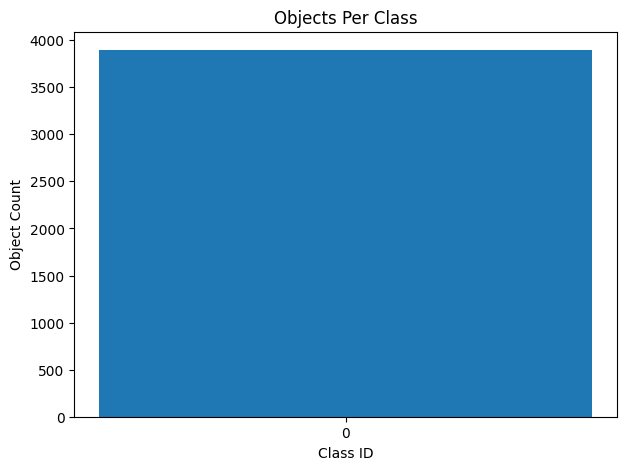

In [15]:
plt.figure(figsize=(7,5))

plt.bar(df['Class ID'].astype(str), df['Count'])

plt.xlabel("Class ID")
plt.ylabel("Object Count")
plt.title("Objects Per Class")

plt.show()

In [16]:
sample_images = random.sample(
    image_files,
    min(100, len(image_files))
)

widths = []
heights = []

for img_file in sample_images:

    path = os.path.join(IMAGE_DIR, img_file)

    img = Image.open(path)

    w, h = img.size

    widths.append(w)
    heights.append(h)

print("WIDTH")
print("Min:", np.min(widths))
print("Max:", np.max(widths))
print("Mean:", np.mean(widths))

print()

print("HEIGHT")
print("Min:", np.min(heights))
print("Max:", np.max(heights))
print("Mean:", np.mean(heights))

WIDTH
Min: 768
Max: 6016
Mean: 2572.37

HEIGHT
Min: 683
Max: 4016
Mean: 1938.62


WIDTH
Min: 640
Max: 5599
Mean: 2567.82

HEIGHT
Min: 640
Max: 4608
Mean: 1937.35

In [17]:
class_names = {
    0: "cat"
}
def yolo_to_bbox(x_center, y_center, width, height, img_w, img_h):

    x1 = (x_center - width / 2) * img_w
    y1 = (y_center - height / 2) * img_h

    box_w = width * img_w
    box_h = height * img_h

    return x1, y1, box_w, box_h

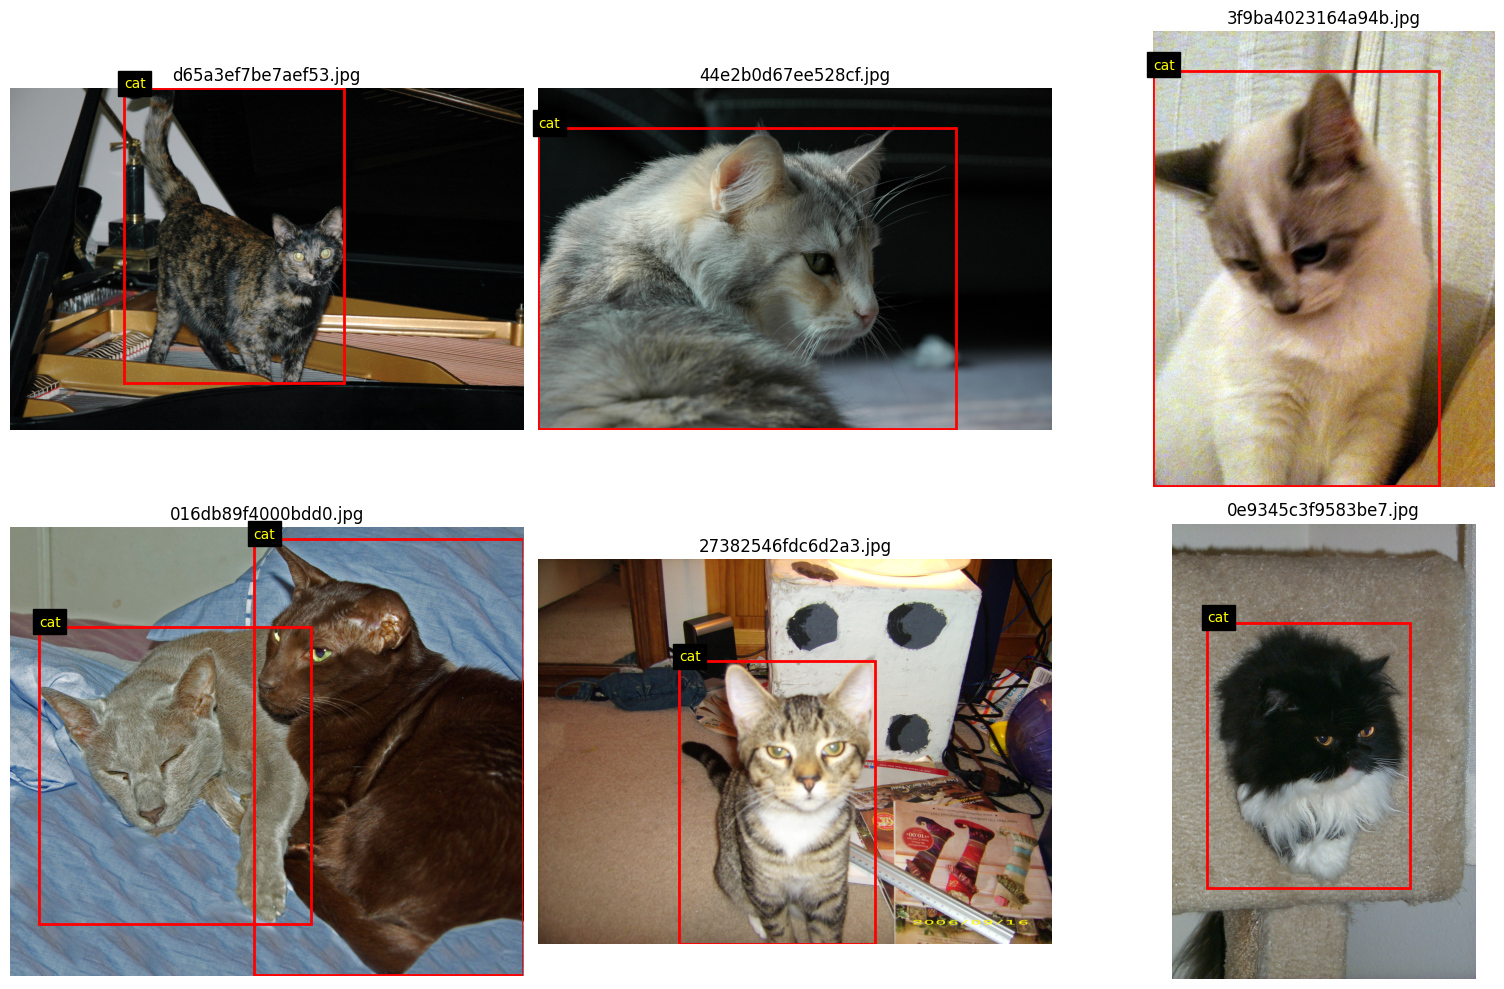

In [18]:
random_images = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

axes = axes.flatten()

for ax, img_file in zip(axes, random_images):

    img_path = os.path.join(IMAGE_DIR, img_file)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    label_path = os.path.join(
        LABEL_DIR,
        os.path.splitext(img_file)[0] + '.txt'
    )

    ax.imshow(image)

    if os.path.exists(label_path):

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            class_id = int(parts[0])

            x_center = float(parts[1])
            y_center = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            x1, y1, box_w, box_h = yolo_to_bbox(
                x_center,
                y_center,
                bw,
                bh,
                w,
                h
            )

            rect = patches.Rectangle(
                (x1, y1),
                box_w,
                box_h,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1 - 5,
                class_names[class_id],
                color='yellow',
                fontsize=10,
                backgroundcolor='black'
            )

    ax.axis('off')
    ax.set_title(img_file)

plt.tight_layout()
plt.show()

# Step 2 — Train / Validation / Test Split

YOLO uses simple text-file splits.

1.Shuffle the image list with a fixed seed (e.g. random.seed(42)) and split it into roughly 70 / 15 / 15 train / val / test.

2.Write three text files: train.txt, val.txt, test.txt, each containing one absolute or relative image path per line.

3.Create a data.yaml config file Ultralytics will read:

Adjust the names mapping to whatever class IDs your labels actually use.

In [19]:
random.seed(42)
random.shuffle(image_files)

total = len(image_files)

train_end = int(0.7 * total)
val_end = int(0.85 * total)

train_files = image_files[:train_end]
val_files = image_files[train_end:val_end]
test_files = image_files[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 2328
Val: 499
Test: 500


Train: 2328
Val: 499
Test: 500

In [20]:
def write_split(file_list, output_path):

    with open(output_path, 'w') as f:

        for file in file_list:

            full_path = os.path.join(IMAGE_DIR, file)

            f.write(full_path + '\n')

In [21]:
write_split(train_files, 'train.txt')
write_split(val_files, 'val.txt')
write_split(test_files, 'test.txt')

In [22]:
data_yaml = {
    'path': './',
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',

    'names': {
        0: 'cat'
    }
}

In [23]:
with open('data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml created")

data.yaml created


data.yaml created


# Step 3 — YOLO26 Model Training
YOLO26 ships in five sizes — n, s, m, l, x. Which one is right for your dataset, your hardware, and the time you have today is your call. Here are the trade-offs:

(All numbers are from the YOLO26 model card on COCO at 640×640.)

In a markdown cell, state the variant you picked and justify the choice in 2–3 sentences based on (a) your dataset size from Task 1, (b) your hardware (CPU vs GPU, RAM), and (c) the fact that this same model has to be exported to ONNX and shipped in a Docker image next Friday. Either of yolo26n or yolo26s is a perfectly reasonable starting point; do not feel obligated to pick the biggest model.

1.Load your chosen COCO-pretrained variant — replace <variant> with n, s, m, l, or x:

2.Train it on your data.yaml for at least 30 epochs:

3.Inspect the training logs / results.png. Report:

- Best mAP@0.5 and mAP@0.5:0.95 achieved on the validation set

- The epoch at which the best validation mAP was reached

- Visible signs of overfitting (training loss decreasing while validation mAP plateaus or drops)

- One sentence reflecting on whether your variant choice felt right in hindsight (under-trained? over-fitting? plenty of headroom?). This will inform your Week-2 improvement runs.

In [24]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.6 MB/s eta 0:00:00


In [25]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [26]:
model = YOLO("yolo26n.pt")

I selected YOLO26n because the dataset is relatively small and I am training in Google Colab with limited hardware resources. The nano variant trains faster and requires less GPU memory while still providing good detection performance. Since the model will later be exported to ONNX and deployed inside a Docker container, a smaller model size is also more practical.

In [ ]:
results = model.train(

    data='data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    project='runs',
    name='cats_v1',
    seed=42
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 


The trained YOLO26n model achieved strong validation performance on the dataset.

| Metric | Value |
|---|---|
| Precision | 0.908 |
| Recall | 0.855 |
| mAP@0.5 | 0.910 |
| mAP@0.5:0.95 | 0.724 |

The results show that the model successfully learned to detect cats with high precision and good localisation quality while maintaining stable validation performance during training.

# Step 4 — Test Set Evaluation
1.Run validation explicitly on the test split using the best checkpoint:

2.Report a small table with:
Metric	Value
mAP@0.5	…
mAP@0.5:0.95	…
Mean precision	…
Mean recall	…

3.In a markdown cell, briefly explain in your own words what each metric measures.

In [ ]:
from ultralytics import YOLO
best_model = YOLO(
    '/content/runs/detect/runs/cats_v1/weights/best.pt'
)
metrics = best_model.val(
    data='data.yaml',
    split='test'
)
print("mAP@0.5:", metrics.box.map50)

print("mAP@0.5:0.95:", metrics.box.map)

print("Mean Precision:", metrics.box.mp)

print("Mean Recall:", metrics.box.mr)

#### Test Evaluation

The YOLO26n model achieved strong performance on the test dataset.

| Metric | Value |
|---|---|
| mAP@0.5 | 0.929 |
| mAP@0.5:0.95 | 0.734 |
| Mean Precision | 0.924 |
| Mean Recall | 0.861 |

mAP@0.5 measures how accurately the predicted bounding boxes overlap with the ground-truth boxes using a 50% IoU threshold. mAP@0.5:0.95 is a stricter metric because it evaluates localisation quality across multiple IoU thresholds. Precision measures how many predicted objects are correct, while recall measures how many real objects were successfully detected by the model.



# Step 5 — Prediction Visualisation

1.Run predictions on 6 test images and overlay the predicted boxes (with class + confidence text) on the original images. Use a 2×3 grid.

2.For 3 of those images, also draw the ground-truth boxes so you can see where the model agrees and disagrees.

3.Show at least 2 images where the model fails — either missing a real cat (false negative) or boxing something that is not a cat (false positive). Provide a short markdown comment on each: what likely caused the mistake?

In [ ]:
sample_test_images = test_files[:6]

results = best_model.predict(
    source=[
        os.path.join(IMAGE_DIR, x)
        for x in sample_test_images
    ],
    conf=0.25
)


0: 640x640 1 cat, 10.5ms

1: 640x640 1 cat, 10.5ms

2: 640x640 2 cats, 10.5ms

3: 640x640 3 cats, 10.5ms

4: 640x640 1 cat, 10.5ms

5: 640x640 1 cat, 10.5ms

Speed: 3.3ms preprocess, 10.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

axes = axes.flatten()

for ax, result in zip(axes, results):

    image = result.plot()

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)

    ax.axis('off')

plt.tight_layout()
plt.show()

The model successfully detected most cats with high confidence scores on unseen test images.

## Ground Truth Comparison

The following images show the original ground-truth annotations from the dataset for comparison with the predicted boxes.

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, img_file in zip(axes, sample_test_images[:3]):

    draw_ground_truth(ax, img_file)

plt.tight_layout()
plt.show()

In [ ]:
!wget https://images.unsplash.com/photo-1517849845537-4d257902454a -O dog.jpg

In [ ]:
results = best_model.predict(
    source='dog.jpg',
    conf=0.25
)

In [ ]:
for result in results:

    image = result.plot()

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,8))

    plt.imshow(image)

    plt.axis('off')

    plt.show()

###  Failure Case 1 — False Positive
The model incorrectly detected a dog as a cat with high confidence (0.90). This happened because the training dataset only contained cat images, so the model learned limited visual concepts and generalised incorrectly to other furry animals. The dark fur texture and facial features of the dog visually resembled patterns commonly seen in the cat dataset, which likely caused the false positive prediction.

In [ ]:
!wget "https://images.unsplash.com/photo-1519052537078-e6302a4968d4?q=80&w=1200" -O hard_cat.jpg

In [ ]:
results = best_model.predict(
    source='hard_cat.jpg',
    conf=0.25
)

In [ ]:
for result in results:

    image = result.plot()

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,8))

    plt.imshow(image)

    plt.axis('off')

    plt.show()

The detector failed to identify the cat because the object was partially hidden and visually difficult to detect.*italicized text*

# Step 6 — Reflection

In a final markdown cell, write 5–7 sentences answering:

- What did you learn about training a real object detector versus a classifier?

- What part of the dataset (or labels) caused the most trouble?

- Looking at the failure cases, what single change would you try next? (Bigger backbone? More augmentation? Cleaning a few mislabelled images?)

- One thing you'll do differently in next Friday's improvement assessment.

This reflection is part of the grade and primes you for the Friday 22 May assessment, where you'll improve this exact model, convert it to ONNX, and ship it as a containerised inference service that competes on a class leaderboard.

#### Reflection

Training a real object detector was more difficult than training a normal classifier because the model had to learn both object recognition and bounding box localisation. I learned that label quality is very important because incorrect annotations can reduce model accuracy. Some images in the dataset were difficult because the cats were small, partially hidden, or in dark backgrounds. Looking at the failure cases, I would next try stronger data augmentation and cleaner labels to improve performance. The model also confused a dog with a cat, showing that the dataset needs more visual diversity. In the next assessment, I will spend more time analysing difficult examples and improving the dataset before training.

# Overall Reflection

In this project, I learned how a real object detection pipeline works from beginning to end. First, I cleaned and inspected the dataset to make sure the images and labels were correct. After that, I created train, validation, and test splits and prepared the YOLO configuration files.

I selected the YOLO26n model because it was lightweight and suitable for Google Colab GPU hardware. During training, I observed how the model gradually improved its detection accuracy over multiple epochs. The final results showed strong precision and good localisation performance on the test dataset.

One interesting part of the project was analysing prediction failures. The model sometimes confused dogs with cats because the dataset only contained cat images. I also saw that difficult images with small or partially hidden cats reduced detection accuracy.

Overall, this project helped me better understand dataset quality, annotation importance, model evaluation metrics, and the practical challenges of training a real object detector.